In [19]:
import pandas as pd
import numpy as np
%pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier

Note: you may need to restart the kernel to use updated packages.


In [20]:
df_ml = pd.read_csv("data/emergency_triage_clean.csv", sep=',', decimal=".",encoding="cp1252")


In [21]:
df_ml['Expert_KTAS'].value_counts().sort_index()

Expert_KTAS
1     26
2    220
3    487
4    459
5     75
Name: count, dtype: int64

1. Which KTAS level has the most patients?  
    KTAS level 3.
2. Which KTAS level has the fewest patients?
    KTAS level 1.
3. Are the five classes balanced?
    Skewed towards the middle, since 3,4 and 2 are the most common.

In [22]:
df_ml['High_acuity'] = np.where(df_ml['Expert_KTAS'] <= 3,'1','0') 
df_ml['High_acuity'] = df_ml['High_acuity'].astype(int)

In [23]:
df_ml['High_acuity'].value_counts()

High_acuity
1    733
0    534
Name: count, dtype: int64

In [24]:
df_ml.head()

,Group,SEX_Female,SEX_Male,Age,AGE_19,AGE_39,AGE_59,AGE_79,AGE_80+,Arrival mode,...,RR,BT,SpO2,Nurse_KTAS,Disposition,Expert_KTAS,KTAS_match,Length of stay_min,KTAS duration_min,High_acuity
0,2,0,1,71,0,0,0,1,0,3,...,18.0,36.6,100.0,2,1,4,False,86,5.00,0
1,1,1,0,56,0,0,1,0,0,3,...,20.0,36.5,NaN,4,1,5,False,64,3.95,0
2,2,1,0,68,0,0,0,1,0,2,...,20.0,36.6,98.0,4,2,5,False,862,1.00,0
3,1,0,1,71,0,0,0,1,0,1,...,20.0,36.5,NaN,4,1,5,False,108,9.83,0
4,1,0,1,58,0,0,1,0,0,3,...,18.0,36.5,NaN,4,1,5,False,109,6.60,0


In [25]:
#df_ml.drop(columns=['Group','Expert_KTAS','Nurse_KTAS','KTAS_match','Disposition','Length of stay_min','KTAS duration_min', 'SEX_Male', 'AGE_19', 'AGE_39', 'AGE_59', 'AGE_79', 'AGE_80+'], inplace=True)
df_ml.head()

,Group,SEX_Female,SEX_Male,Age,AGE_19,AGE_39,AGE_59,AGE_79,AGE_80+,Arrival mode,...,RR,BT,SpO2,Nurse_KTAS,Disposition,Expert_KTAS,KTAS_match,Length of stay_min,KTAS duration_min,High_acuity
0,2,0,1,71,0,0,0,1,0,3,...,18.0,36.6,100.0,2,1,4,False,86,5.00,0
1,1,1,0,56,0,0,1,0,0,3,...,20.0,36.5,NaN,4,1,5,False,64,3.95,0
2,2,1,0,68,0,0,0,1,0,2,...,20.0,36.6,98.0,4,2,5,False,862,1.00,0
3,1,0,1,71,0,0,0,1,0,1,...,20.0,36.5,NaN,4,1,5,False,108,9.83,0
4,1,0,1,58,0,0,1,0,0,3,...,18.0,36.5,NaN,4,1,5,False,109,6.60,0


Is the binary target reasonably balanced?
    No, there is almost a 8 to 2 ratio of low acuity to high acuity.

In [ ]:
# numeric_features = ['Age','NRS_pain','SBP','DBP','HR','RR','BT','SpO2']
numeric_features = ['NRS_pain','SBP','DBP','HR','RR','BT','SpO2']
categorical_features = ['Arrival mode','Injury','Mental','Pain']
hotcodealready = []
features = numeric_features + categorical_features + hotcodealready
x = df_ml[features]
y = df_ml['High_acuity']


In [27]:
df_ml.head()

,Group,SEX_Female,SEX_Male,Age,AGE_19,AGE_39,AGE_59,AGE_79,AGE_80+,Arrival mode,...,RR,BT,SpO2,Nurse_KTAS,Disposition,Expert_KTAS,KTAS_match,Length of stay_min,KTAS duration_min,High_acuity
0,2,0,1,71,0,0,0,1,0,3,...,18.0,36.6,100.0,2,1,4,False,86,5.00,0
1,1,1,0,56,0,0,1,0,0,3,...,20.0,36.5,NaN,4,1,5,False,64,3.95,0
2,2,1,0,68,0,0,0,1,0,2,...,20.0,36.6,98.0,4,2,5,False,862,1.00,0
3,1,0,1,71,0,0,0,1,0,1,...,20.0,36.5,NaN,4,1,5,False,108,9.83,0
4,1,0,1,58,0,0,1,0,0,3,...,18.0,36.5,NaN,4,1,5,False,109,6.60,0


Answer the following question:

Why should these columns not be used to predict expert KTAS?

    They can lead to the answer without the use of input, so the machine won't really learn as the answer key is already in the data.


In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

Answer:

Why is `stratify=y` useful for classification?

It maintains the ratio of input so that the test or training subset does not take all of a certain type of data, i.e. especially high values or especially low values.


In [29]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('hot', 'passthrough', hotcodealready)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


Answer:

Why should `Arrival mode` not be treated as a continuous measurement?

    These numbers actually represent a type of transporation, not a measurement concerning arrival mode. 


In [30]:
print(len(y_pred))
print(np.unique(y_pred))
pd.Series(y_pred).value_counts()

254
[0 1]


1    154
0    100
Name: count, dtype: int64

In [31]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

logreg = model.named_steps["classifier"]

coef = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

coef_df.sort_values(
    "coefficient",
    key=abs,
    ascending=False
)

,feature,coefficient
11,cat__Injury_1,1.074970
12,cat__Injury_2,-1.023900
0,num__NRS_pain,0.895776
6,cat__Arrival mode_3,-0.888758
16,cat__Mental_4,0.818480
8,cat__Arrival mode_5,0.719372
13,cat__Mental_1,-0.658574
7,cat__Arrival mode_4,0.613152
14,cat__Mental_2,-0.541820
4,cat__Arrival mode_1,-0.526315


In [32]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print (accuracy)
print(precision)
print(recall)
print(f1)

0.6653543307086615
0.7012987012987013
0.7346938775510204
0.717607973421927


Answer:

1. What percentage of all test records was predicted correctly?
    84%
2. When the model predicted higher acuity, how often was it correct?
    71%
3. How many actual higher-acuity patients did the model identify?
    30%
4. Which metric would be especially important when missing a higher-acuity patient is a concern?
    Recall

In [33]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Lower acuity", "Higher acuity"]
))

               precision    recall  f1-score   support

 Lower acuity       0.61      0.57      0.59       107
Higher acuity       0.70      0.73      0.72       147

     accuracy                           0.67       254
    macro avg       0.66      0.65      0.65       254
 weighted avg       0.66      0.67      0.66       254



Does the model perform similarly for both classes?

It works better for lower acuity than the higher acuity.

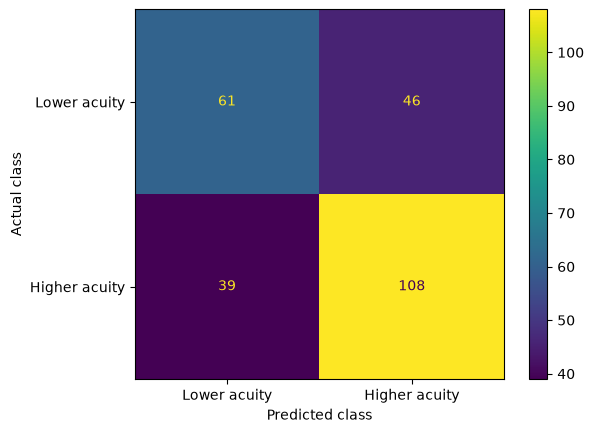

In [34]:
cm = confusion_matrix(y_test,y_pred)
cfd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower acuity", "Higher acuity"]
)
cfd.plot()
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()


How many higher-acuity patients were incorrectly predicted as lower acuity?
    34 patients.

In [35]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(x_train, y_train)

y_pred_baseline = baseline.predict(x_test)
accuracy = accuracy_score(y_test, y_pred_baseline)
print(accuracy)

print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Lower acuity", "Higher acuity"]
))

0.5787401574803149
               precision    recall  f1-score   support

 Lower acuity       0.00      0.00      0.00       107
Higher acuity       0.58      1.00      0.73       147

     accuracy                           0.58       254
    macro avg       0.29      0.50      0.37       254
 weighted avg       0.33      0.58      0.42       254



c:\Users\1\Downloads\emergency-triage-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\1\Downloads\emergency-triage-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\1\Downloads\emergency-triage-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

Answer:

1. Does Logistic Regression perform better than the baseline?
    Yes.
2. Why is comparison with a baseline important?
    To see what a model is good at, and what it is not good at. 
3. Would accuracy alone be enough to compare the models?
    No, we need to consider precesion, recall and f1-score of both classes.

In [36]:
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy)
print(classification_report(
    y_test,
    predictions,
    target_names=["Lower acuity", "Higher acuity"]
))

0.7204724409448819
               precision    recall  f1-score   support

 Lower acuity       0.71      0.56      0.63       107
Higher acuity       0.72      0.84      0.78       147

     accuracy                           0.72       254
    macro avg       0.72      0.70      0.70       254
 weighted avg       0.72      0.72      0.71       254



Which model would you select, and why?
    I would select the linear regression model, because it still has higher precision for higher acuity, but to be honest none of these models are very great. 

1. What was the prediction target?
    Lower or higher acuity level.
2. Why were KTAS levels grouped into two classes?
    So that it's easier to predict, more range per class so the chance of getting something right should be easier.
3. How many patients belonged to each target class?
    1021 in the low acuity class and 246 in the higher acuity class.
4. Which variables were used as model inputs?
    Age,NRS_pain,SBP,DBP,HR,RR,BT,SpO2,Sex,Arrival mode,injury, mental and pain
5. Which variables were excluded to prevent target leakage?
    Expert_KTAS,Nurse_KTAS,KTAS_mathc,mistriage,Error_group,Diagnosis in ED, Disposition, Length of stay_min, Gorup, KTAS duration_min
6. How were missing numeric values handled?
    Turned into median for numeric input, and most common for categorical
7. How were categorical features encoded?
    Using a one hot encoder.
8. What were the model's accuracy, precision, recall, and F1-score?
    84%,71%,31% and 43%
9. How many higher-acuity cases were missed?
    34 high acuity cases were missed.
10. Did the model perform better than the baseline?
    
11. Which evaluation metric was the most important for this problem?
    Recall.
12. What limitations does this model have?

13. What additional data might improve the model?
    Cheif complaint, 